https://huggingface.co/docs/transformers/model_doc/bert

In [1]:
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
from torch.utils.data import DataLoader
torch.cuda.is_available()

True

In [3]:
print(torch.cuda.device_count())
print(torch.cuda.current_device())

1
0


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(device=None, abbreviated=False))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [6]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset

/home/arman/miniforge3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, attn_implementation="eager")
model.to(device)

freezed_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2, attn_implementation="eager")
freezed_model.to(device)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3519.66it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2784.62it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-b

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [8]:
inputs = tokenizer("rubbish", return_tensors="pt").to(device)
outputs = model(**inputs)
pred = torch.argmax(outputs.logits, dim=1).item()
pred


1

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [10]:
dataset = load_dataset("imdb")

In [11]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [12]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [13]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50000
    })
})

In [14]:
train_loader = DataLoader(dataset["train"], batch_size=64, shuffle=True)
test_loader = DataLoader(dataset["test"], batch_size=64)

In [15]:
def train_model_iter():
    model.train()

    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            labels=batch["label"].to(device)
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

    print("epoch finished")

In [16]:
def count_accuracy() -> float:
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

In [18]:
start_time = time.monotonic()
accuracy = count_accuracy()
print("start accuracy", time.monotonic() - start_time, "===", accuracy)

for epoch in range(3):
    start_time = time.monotonic()
    train_model_iter()
    print("end epoch", epoch, time.monotonic() - start_time)

    start_time = time.monotonic()
    accuracy = count_accuracy()
    print("get accuracy on epoch", epoch, time.monotonic() - start_time, "===", accuracy)

start accuracy 100.73211686800005 === 0.49944
epoch finished
end epoch 0 248.84474411500014
get accuracy on epoch 0 102.98464609199982 === 0.87248
epoch finished
end epoch 1 249.43281545499985
get accuracy on epoch 1 102.7498611609999 === 0.87848
epoch finished
end epoch 2 248.79356933000008
get accuracy on epoch 2 102.77442413400013 === 0.87652


prediction 0


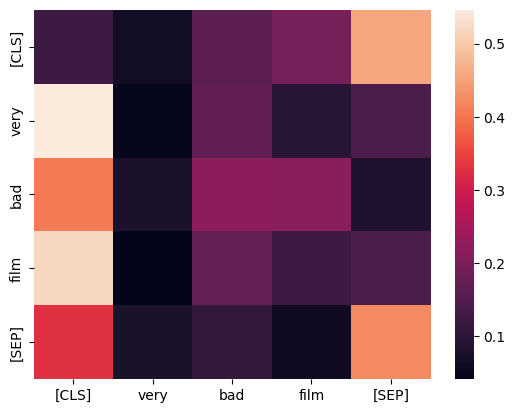

In [19]:
inputs = tokenizer(
    "very bad film",
    return_tensors="pt"
).to(device)

outputs = model(**inputs, output_attentions=True)

logits = outputs.logits
attentions = outputs.attentions
pred = torch.argmax(logits, dim=1).item()
print(f"prediction {pred}")

att = attentions[0][0][0].detach().cpu().numpy()

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

sns.heatmap(att, xticklabels=tokens, yticklabels=tokens)
plt.show()

In [20]:
def demonstrate(
    text: str,
    expected: int,
):
    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(device)

    outputs = model(**inputs, output_attentions=True)
    outputs_from_freezed = freezed_model(**inputs, output_attentions=True)

    pred = torch.argmax(outputs.logits, dim=1).item()
    pred_from_freezed = torch.argmax(outputs_from_freezed.logits, dim=1).item()
    print(f"text {text}")
    print(f"prediction from fine-tuned {pred}")
    print(f"prediction from freezed {pred_from_freezed}")
    print(f"expected {expected}")

    att = outputs.attentions[0][0][0].detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

    sns.heatmap(att, xticklabels=tokens, yticklabels=tokens)
    plt.show()

In [24]:
dataset = load_dataset("imdb")
samples = list(dataset["test"])
samples.sort(key=lambda x: len(x["text"]))
len(samples[0]), samples[0]

(2, {'text': 'Read the book, forget the movie!', 'label': 0})

text Read the book, forget the movie!
prediction from fine-tuned 0
prediction from freezed 0
expected 0


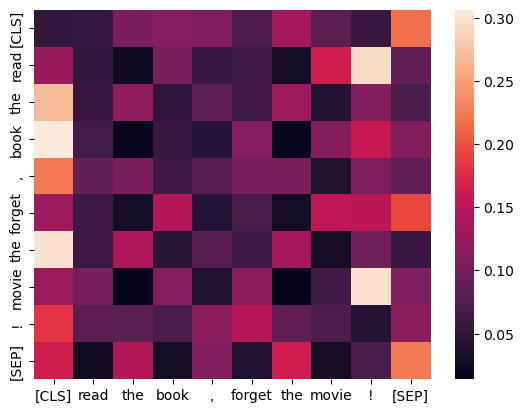

In [25]:
demonstrate(samples[0]["text"], samples[0]["label"])

text What a script, what a story, what a mess!
prediction from fine-tuned 0
prediction from freezed 0
expected 0


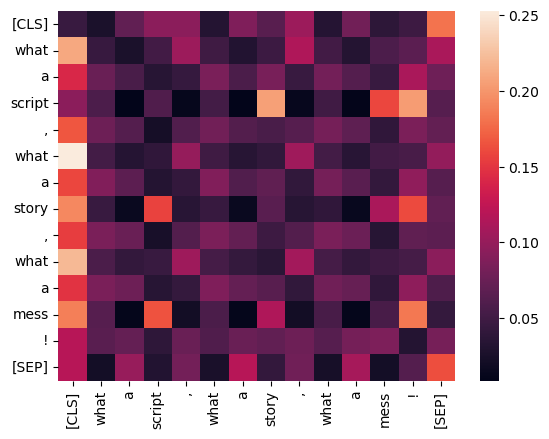

In [26]:
demonstrate(samples[1]["text"], samples[1]["label"])

text I hope this group of film-makers never re-unites.
prediction from fine-tuned 0
prediction from freezed 0
expected 0


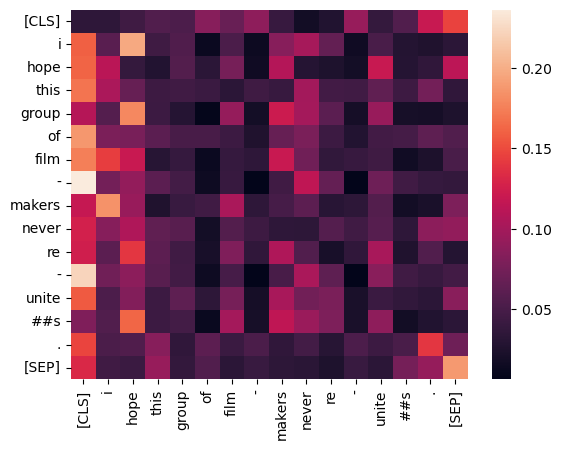

In [27]:
demonstrate(samples[2]["text"], samples[2]["label"])

text Primary plot!Primary direction!Poor interpretation.
prediction from fine-tuned 0
prediction from freezed 0
expected 0


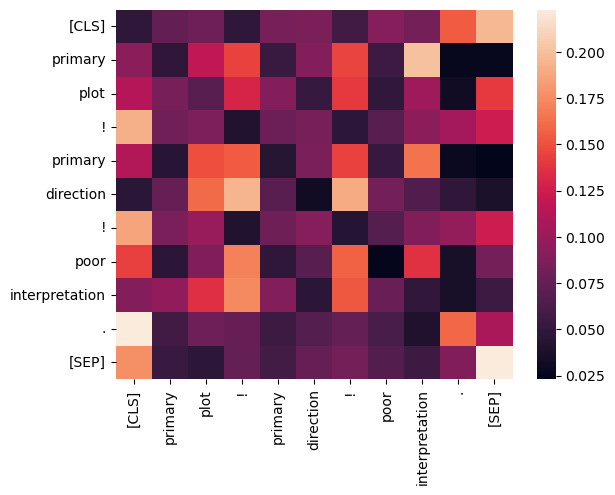

In [28]:
demonstrate(samples[3]["text"], samples[3]["label"])

text More suspenseful, more subtle, much, much more disturbing....
prediction from fine-tuned 1
prediction from freezed 0
expected 0


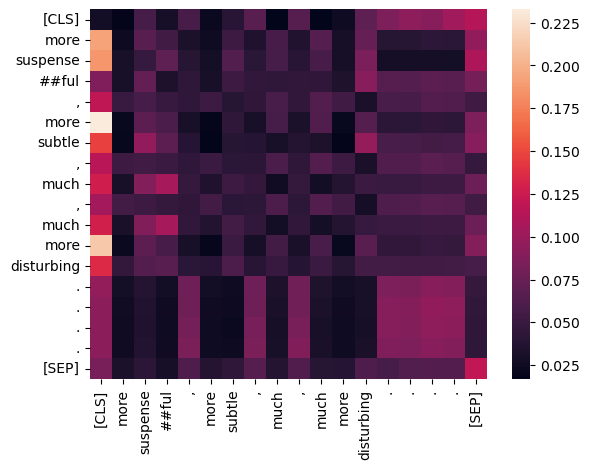

In [29]:
demonstrate(samples[4]["text"], samples[4]["label"])